# Building the Knowledge-based Metabolic Network

This notebook is used to build the knowledge-based metabolic network used to supplement the FDiNs for the FDiGNN approach. This metabolic networks is used based on all reactions from the Small Molecule Pathway Database (SMPDB) by joining every reactant to every product.

### Notebook Organization:

- Set up functions for pathway and reaction extraction from SMBL files.
- Extracting Information from SBML and compiling it.
- Show example of metabolic pathways (pentose phosphate pathway).
- Using information to build metabolic network.

## Warning: This notebook cannot be run without the SBML files from the SMPDB database. To obtain these files, go to https://smpdb.ca/downloads and download the `SBML files`. Unzip them into a folder called `smpdb_sbml` in the same folder as this notebook.

#### Necessary Imports

In [1]:
import pandas as pd
import numpy as np
from xml.etree import ElementTree 
import warnings
import networkx as nx
import matplotlib.pyplot as plt
import os.path
warnings.filterwarnings("ignore")

## Functions for parsing SMBL files

In [2]:
def readSMBLfiles(filename):
    "Read SBML file."
    tree = ElementTree.parse(open(filename))
    #tree = _
    #tree.getroot()
    root = tree.getroot()
    return root

In [3]:
def extract_compounds(root):
    "Extract compounds to a DataFrame from a read SBML pathway file (SMPDB)."
    
    compounds = pd.DataFrame(columns= ['Name', 'HMDB'])
    species = root.findall("*/*/{http://www.sbml.org/sbml/level3/version1/core}species")
    for s in species:
        if s.attrib['id'].startswith('Compound'): # Find compounds
            # Obtain compound info and store it
            sid = s.attrib['id']
            name = s.attrib['name']
            annotation = list(s)[0]
            rdf = list(annotation)[1]
            description =  list(rdf)[0]
            _is = list(description)[0]
            bag = list(_is)[0]

            # Different whether compound has or does not have HMDB ID
            if len(list(bag)) >= 2:
                hmdb_resource = list(bag)[1].attrib
                hmdb_split = hmdb_resource['{http://www.w3.org/1999/02/22-rdf-syntax-ns#}resource'].split(':')
                hmdb = hmdb_split[3]
            else:
                hmdb = ''
            new_row = pd.DataFrame({'Name': name, 'HMDB': hmdb}, index=[sid])
            compounds = pd.concat([compounds, new_row])
    
    return compounds

In [4]:
def extract_reactions(root):
    "Extract reactions to a DataFrame from a read SBML pathway file (SMPDB)."
    
    reactions = pd.DataFrame(columns= ['Name', 'Reversible', 'Reactants', 'Products'])
    reacs = root.findall("*/*/{http://www.sbml.org/sbml/level3/version1/core}reaction")
    for r in reacs:
        if r.attrib['id'].startswith('Reaction'): # Find reactions
            # Guarantee that the reaction has reactants and products
            if len(list(r)) >= 3:
                if list(r)[1].tag == '{http://www.sbml.org/sbml/level3/version1/core}listOfReactants':
                    if list(r)[2].tag == '{http://www.sbml.org/sbml/level3/version1/core}listOfProducts':
                        # Obtain reaction info and store it
                        rid = r.attrib['id']
                        name = r.attrib['name']
                        reversible = r.attrib['reversible']
                        reactants = []
                        products = []
                        get_reactants = list(r)[1]
                        get_products = list(r)[2]
                        for r1 in get_reactants:
                            reactants.append(r1.attrib['species'])
                        for p1 in get_products:
                            products.append(p1.attrib['species'])
                        new_row = pd.DataFrame({'Name': name, 'Reversible': reversible, 'Reactants': str(reactants), 
                                                'Products': str(products)}, index=[rid])
                        reactions = pd.concat([reactions, new_row])
    
    return reactions

In [5]:
def parsing_SMBL_files(filename):
    "Obtain compound and reaction DataFrames from a SPMDB pathway file (SBML file)."
    
    root = readSMBLfiles(filename) # Read file
    compounds = extract_compounds(root) # Obtain Compounds
    reactions = extract_reactions(root) # Obtain Reactions
    
    return compounds, reactions

### Info about pathways

Reading general file on pathways

In [6]:
path_info = pd.read_csv('smpdb_pathways.csv')
#path_info = pd.read_csv('pathbank_pathways.csv')

# Types of pathways
for i in set(list(path_info['Subject'])):
    print(i, list(path_info['Subject']).count(i))

Protein 76
Drug Metabolism 64
Physiological 16
Signaling 13
Metabolic 27882
Drug Action 404
Disease 20248


In [7]:
path_info = path_info.set_index('PW ID')
path_info#.tail(50)

,SMPDB ID,Name,Subject,Description
PW ID,,,,
PW000001,SMP0000055,Alanine Metabolism,Metabolic,Alanine (L-Alanine) is an α-amino acid that is...
PW000002,SMP0000067,Aspartate Metabolism,Metabolic,Aspartate is synthesized by transamination of ...
PW000003,SMP0000072,Glutamate Metabolism,Metabolic,Glutamate is one of the non-essential amino ac...
PW000004,SMP0000015,Glutathione Metabolism,Metabolic,Glutathione (GSH) is an low-molecular-weight t...
PW000005,SMP0000057,Citric Acid Cycle,Metabolic,"The citric acid cycle, which is also known as ..."
...,...,...,...,...
PW122328,SMP0121060,Kandutsch-Russell Pathway (Cholesterol Biosynt...,Metabolic,The Kandutsch-Russell pathway is the alternati...
PW122396,SMP0121123,Arsenate Detoxification,Metabolic,"Arsenate is a compound similar to phosphate, b..."
PW122401,SMP0121126,Aldosterone from Steroidogenesis,Physiological,Aldosterone is a hormone produced in the zona ...


In [8]:
tag = 0
pel = 0
pc = 0
cl = 0
others = 0
for i in path_info[path_info['Subject'] == 'Metabolic']['Name']:
    if i.startswith('De Novo Triacylglycerol Biosynthesis'):
        tag +=1
    elif i.startswith('Phosphatidylethanolamine Biosynthesis'):
        pel +=1
    elif i.startswith('Phosphatidylcholine Biosynthesis'):
        pc += 1
    elif i.startswith('Cardiolipin Biosynthesis'):
        cl += 1
    else:
        others += 1
print(f'De Novo Triacylglycerol Biosynthesis pathways: {tag}')
print(f'Phosphatidylethanolamine Biosynthesis pathways: {pel}')
print(f'Phosphatidylcholine Biosynthesis pathways: {pc}')
print(f'Cardiolipin Biosynthesis pathways: {cl}')
print(f'All other pathways: {others}')

De Novo Triacylglycerol Biosynthesis pathways: 22657
Phosphatidylethanolamine Biosynthesis pathways: 923
Phosphatidylcholine Biosynthesis pathways: 923
Cardiolipin Biosynthesis pathways: 3278
All other pathways: 101


## Extracting pathway and reaction information

`comp_store` - Compound Pathway Information
`react_store` - Reaction Pathway Information

In [9]:
# Storage for compounds and reactions
from tqdm import tqdm
comp_store = {}
react_store = {}

for num in tqdm(range(1, 120529)):
    # Construct the files names
    num_str = str(num)
    zeros = '0'*(6-len(num_str))
    filename = 'smpdb_sbml\PW' + zeros + num_str + '.sbml'
    
    if os.path.isfile(filename): # Guarantee file exists (not all numbers have a corresponding file)
        
        # Select only pathways that correspond to Metabolic Pathways
        if path_info.loc['PW'+zeros+num_str, 'Subject'] == 'Metabolic':
            # Obtain compounds and reactions, and store them
            c, r = parsing_SMBL_files(filename)

            comp_store[zeros + num_str] = c
            react_store[zeros + num_str] = r

            #print(filename)

100%|█████████████████████████████████████████████████████████████████████████| 120528/120528 [10:27<00:00, 192.11it/s]


In [10]:
# Gathering pathway information
full_pathways = {}

for c in comp_store:
    #print(comp_store[c])
    #print('PW'+c)
    for comp in comp_store[c].index:
        #print(comp_store[c].loc[comp, 'HMDB'])
        hmdb_id = comp_store[c].loc[comp, 'HMDB']
        if hmdb_id in full_pathways.keys():
            full_pathways[hmdb_id]['Pathway Name'].append(path_info.loc['PW'+c, 'Name'])
            full_pathways[hmdb_id]['Pathway ID'].append(path_info.loc['PW'+c, 'SMPDB ID'])
        else:
            full_pathways[hmdb_id] = {}
            full_pathways[hmdb_id]['Pathway Name'] = [path_info.loc['PW'+c, 'Name'],]
            full_pathways[hmdb_id]['Pathway ID'] = [path_info.loc['PW'+c, 'SMPDB ID'],]
    #print(path_info.loc['PW'+c, 'Name'])

In [11]:
# File with detecteed pathways for each HMDB compound
pd.DataFrame(full_pathways).T.to_excel('pathways_name.xlsx')

## Example Pathway 55 - Pentose Phosphate Pathway

In [12]:
# Setting up a Directed Graph and adding nodes
pathway55 = nx.DiGraph()
pathway55.add_nodes_from(comp_store['000055'].index)

# Adding node attributes
nx.set_node_attributes(pathway55, comp_store['000055']['Name'], 'Name')
nx.set_node_attributes(pathway55, comp_store['000055']['HMDB'], 'HMDB_i')

In [13]:
for react in react_store['000055'].index:
    # Reactants, Products and Reversability
    reactants = react_store['000055'].loc[react, 'Reactants'][2:-2].split("', '")
    #print(reactants)
    products = react_store['000055'].loc[react, 'Products'][2:-2].split("', '")
    if react_store['000055'].loc[react, 'Reversible'] == 'true':
        reversible = True
    else:
        reversible = False
    
    # Adding Edges to Network
    for r in reactants:
        for p in products:
            pathway55.add_edge(r, p, reaction = react)
            if reversible:
                pathway55.add_edge(p, r, reaction = react)

In [14]:
# Remove nodes without connections
degrees = dict(pathway55.degree())
for node, deg in degrees.items():
    if deg == 0:
        pathway55.remove_node(node)

for node in list(pathway55.nodes()):
    if node.startswith('ProteinComplex'):
        pathway55.remove_node(node)

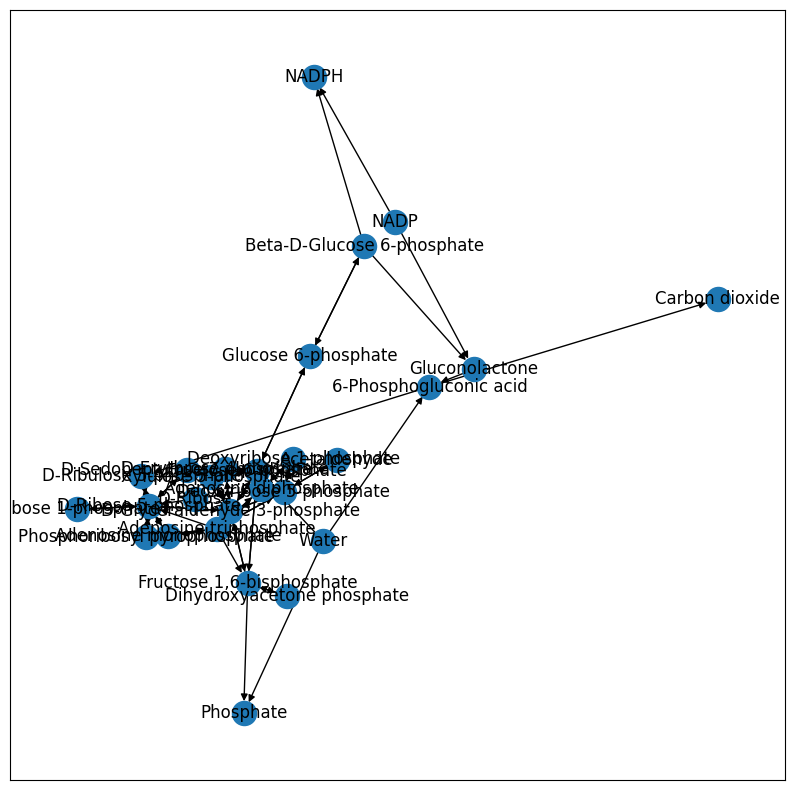

In [15]:
# Draw Graph
f, ax = plt.subplots(1,1, figsize=(10,10))
nx.draw_networkx(pathway55, labels=nx.get_node_attributes(pathway55, 'Name'))

In [16]:
# Pagerank attempt
pagerank_path = nx.pagerank(pathway55)
sorted_pagerank = sorted(pagerank_path.items(), key=lambda item: item[1], reverse=True)
sorted_pagerank

[('Compound1191', 0.10238718767397584),
 ('Compound869', 0.08400269930129847),
 ('Compound79', 0.08179940219632022),
 ('Compound414', 0.06721471247364685),
 ('Compound813', 0.06350046728835754),
 ('Compound843', 0.05892239697681363),
 ('Compound691', 0.05474271169784007),
 ('Compound833', 0.05452719060826989),
 ('Compound1034', 0.04700207997844808),
 ('Compound1019', 0.041556392303374164),
 ('Compound1042', 0.04067046664762551),
 ('Compound190', 0.031227718780972934),
 ('Compound32', 0.031227718780972934),
 ('Compound479', 0.031025893193212913),
 ('Compound1015', 0.021929901422247502),
 ('Compound1083', 0.021799597590603202),
 ('Compound1146', 0.021705669389956148),
 ('Compound1104', 0.0208285244487968),
 ('Compound784', 0.020694819073562205),
 ('Compound1134', 0.018788149738327237),
 ('Compound1316', 0.016521557046959057),
 ('Compound1906', 0.016466114518475645),
 ('Compound97', 0.01492731456941792),
 ('Compound146', 0.01492731456941792),
 ('Compound143', 0.007201333243702295),
 ('Com

In [17]:
# Translating general compound names to their actual names
named_pagerank = []
for i in sorted_pagerank:
    named_pagerank.append((comp_store['000055'].loc[i[0], 'Name'], i[1]))
dict(named_pagerank)

{'D-Ribose 5-phosphate': 0.10238718767397584,
 'D-Glyceraldehyde 3-phosphate': 0.08400269930129847,
 'Fructose 6-phosphate': 0.08179940219632022,
 'Adenosine triphosphate': 0.06721471247364685,
 'Deoxyribose 5-phosphate': 0.06350046728835754,
 'D-Sedoheptulose 7-phosphate': 0.05892239697681363,
 'Xylulose 5-phosphate': 0.05474271169784007,
 'Fructose 1,6-bisphosphate': 0.05452719060826989,
 'Adenosine diphosphate': 0.04700207997844808,
 'D-Erythrose 4-phosphate': 0.041556392303374164,
 'Deoxyribose 1-phosphate': 0.04067046664762551,
 'Phosphoribosyl pyrophosphate': 0.031227718780972934,
 'Adenosine monophosphate': 0.031227718780972934,
 'D-Ribulose 5-phosphate': 0.031025893193212913,
 '6-Phosphogluconic acid': 0.021929901422247502,
 'Glucose 6-phosphate': 0.021799597590603202,
 'Ribose 1-phosphate': 0.021705669389956148,
 'Phosphate': 0.0208285244487968,
 'Acetaldehyde': 0.020694819073562205,
 'Dihydroxyacetone phosphate': 0.018788149738327237,
 'Carbon dioxide': 0.016521557046959057,


## Using information to build metabolic network

#### Compound-based network

In [18]:
# Setting up a Directed Graph and adding nodes
pathways = nx.Graph()

# For each pathway
for c in comp_store.keys():
    for a in comp_store[c].index:
        if a in pathways.nodes():
            pathways.nodes()[a]['Pathway'].append(path_info.loc['PW'+c, 'Name'])
            pathways.nodes()[a]['SMPDB_ID'].append(path_info.loc['PW'+c, 'SMPDB ID'])
        else:
            pathways.add_node(a, Name = comp_store[c].loc[a, 'Name'], HMDB_i = comp_store[c].loc[a, 'HMDB'],
                             SMPDB_ID = [path_info.loc['PW'+c, 'SMPDB ID'],], Pathway = [path_info.loc['PW'+c, 'Name'],])

In [19]:
print(len(pathways.nodes()))

34454


In [20]:
# For each pathway
for a, reactions in react_store.items():
    for react in reactions.index:
        # Reactants, Products and Reversability
        reactants = reactions.loc[react, 'Reactants'][2:-2].split("', '")
        products = reactions.loc[react, 'Products'][2:-2].split("', '")

        # Adding Edges to Network
        for r in reactants:
            for p in products:
                if (r, p) in pathways.edges():
                    if path_info.loc['PW'+a, 'Name'] not in pathways.edges()[(r, p)]['Pathway']:
                        pathways.edges()[(r, p)]['Pathway'].append(path_info.loc['PW'+a, 'Name'])
                        pathways.edges()[(r, p)]['SMPDB_ID'].append(path_info.loc['PW'+a, 'SMPDB ID'])
                else:
                    pathways.add_edge(r, p, reaction = react, Pathway = [path_info.loc['PW'+a, 'Name'],],
                                     SMPDB_ID = [path_info.loc['PW'+a, 'SMPDB ID'],])
                    
    #print(a)

In [21]:
print(len(pathways.edges()))

82268


In [22]:
# Example edge
pathways.edges()[('Compound414', 'Compound32')]

{'reaction': 'Reaction1',
 'Pathway': ['Alanine Metabolism',
  'Aspartate Metabolism',
  'Glutamate Metabolism',
  'Selenoamino Acid Metabolism',
  'Ammonia Recycling',
  'Arginine and Proline Metabolism',
  'Butyrate Metabolism',
  'Cysteine Metabolism',
  'Ethanol Degradation',
  'Fatty Acid Metabolism',
  'Phenylacetate Metabolism',
  'Thiamine Metabolism',
  'Phenylalanine and Tyrosine Metabolism',
  'Histidine Metabolism',
  'Purine Metabolism',
  'Pyruvate Metabolism',
  'Pentose Phosphate Pathway',
  'Methionine Metabolism',
  'Propanoate Metabolism',
  'Nicotinate and Nicotinamide Metabolism',
  'Glycine and Serine Metabolism',
  'Urea Cycle',
  'Tryptophan Metabolism',
  'Mitochondrial Beta-Oxidation of Short Chain Saturated Fatty Acids',
  'Mitochondrial Beta-Oxidation of Medium Chain Saturated Fatty Acids',
  'Mitochondrial Beta-Oxidation of Long Chain Saturated Fatty Acids'],
 'SMPDB_ID': ['SMP0000055',
  'SMP0000067',
  'SMP0000072',
  'SMP0000029',
  'SMP0000009',
  'SMP0

In [23]:
# Example Node
pathways.nodes()['Compound414']

{'Name': 'Adenosine triphosphate',
 'HMDB_i': 'HMDB0000538',
 'SMPDB_ID': ['SMP0000055',
  'SMP0000067',
  'SMP0000072',
  'SMP0000015',
  'SMP0000057',
  'SMP0000029',
  'SMP0000045',
  'SMP0000009',
  'SMP0000020',
  'SMP0000123',
  'SMP0000066',
  'SMP0000073',
  'SMP0000013',
  'SMP0000449',
  'SMP0000051',
  'SMP0000053',
  'SMP0000064',
  'SMP0000010',
  'SMP0000027',
  'SMP0000126',
  'SMP0000070',
  'SMP0000076',
  'SMP0000445',
  'SMP0000041',
  'SMP0000450',
  'SMP0000008',
  'SMP0000044',
  'SMP0000444',
  'SMP0000023',
  'SMP0000032',
  'SMP0000050',
  'SMP0000060',
  'SMP0000031',
  'SMP0000033',
  'SMP0000011',
  'SMP0000039',
  'SMP0000035',
  'SMP0000040',
  'SMP0000034',
  'SMP0000016',
  'SMP0000058',
  'SMP0000048',
  'SMP0000128',
  'SMP0000457',
  'SMP0000466',
  'SMP0000030',
  'SMP0000462',
  'SMP0000004',
  'SMP0000043',
  'SMP0000046',
  'SMP0000052',
  'SMP0000059',
  'SMP0000063',
  'SMP0000355',
  'SMP0000452',
  'SMP0000463',
  'SMP0000467',
  'SMP0000480',

In [24]:
print('Nº of nodes:', len(pathways.nodes()))
print('Nº of edges:', len(pathways.edges()))
print('Nº of self loops:', nx.number_of_selfloops(pathways))

Nº of nodes: 34545
Nº of edges: 82268
Nº of self loops: 9


In [25]:
# Remove nodes that do not correspond to compounds
# Can be added sometimes when Protein Complexes or other not compounds are a part of some reactions
for node in list(pathways.nodes()):
    if not node.startswith('Compound'):
        pathways.remove_node(node)
        
# Remove self loop edges
for ed in nx.selfloop_edges(pathways):
    pathways.remove_edge(ed[0], ed[1])
    
# Remove nodes without connections  Done later on now
#degrees = dict(pathways.degree())
#for node, deg in degrees.items():
#    if deg == 0:
#        pathways.remove_node(node)

In [26]:
print('Nº of nodes:', len(pathways.nodes()))
print('Nº of edges:', len(pathways.edges()))
print('Nº of self loops:', nx.number_of_selfloops(pathways))

Nº of nodes: 34454
Nº of edges: 81945
Nº of self loops: 0


In [27]:
print('Nº of nodes:', len(pathways.nodes()))
print('Nº of edges:', len(pathways.edges()))
print('Nº of self loops:', nx.number_of_selfloops(pathways))

Nº of nodes: 34454
Nº of edges: 81945
Nº of self loops: 0


In [28]:
# Component size
for i in sorted(nx.connected_components(pathways), key=len, reverse=True):
    if len(i) > 1:
        print(len(i))

34419
2


### Filter Network to only include compounds with associated HMDB identifiers

Exclude all non-HMDB and non-metabolite compounds

In [29]:
# Remove nodes without HMDB identifiers
nodes_to_remove = []
for node in pathways.nodes():
    if 'HMDB' not in pathways.nodes()[node]['HMDB_i']:
        nodes_to_remove.append(node)

pathways.remove_nodes_from(nodes_to_remove)
print(len(pathways.nodes()))

17358


In [30]:
print(len(pathways.edges()))

32686


In [31]:
# Read HMDB database
hmdb = pd.read_csv('filtered_hmdb.csv').set_index('accession')
hmdb

,monoisotopic_molecular_weight,iupac_name,name,chemical_formula,InChIKey,cas_registry_number,smiles,drugbank,chebi_id,pubchem,...,bigg,metlin_id,pdb_id,logpexp,kingdom,direct_parent,super_class,class,sub_class,molecular_framework
accession,,,,,,,,,,,,,,,,,,,,,
HMDB0000001,169.085127,b'(2S)-2-amino-3-(1-methyl-1H-imidazol-4-yl)pr...,1-Methylhistidine,C7H11N3O2,BRMWTNUJHUMWMS-LURJTMIESA-N,332-80-9,CN1C=NC(C[C@H](N)C(O)=O)=C1,DB04151,50599.0,92105.0,...,NaN,3741.0,NaN,NaN,Organic compounds,Histidine and derivatives,Organic acids and derivatives,Carboxylic acids and derivatives,"Amino acids, peptides, and analogues",Aromatic heteromonocyclic compounds
HMDB0000005,102.031694,b'2-oxobutanoic acid',2-Ketobutyric acid,C4H6O3,TYEYBOSBBBHJIV-UHFFFAOYSA-N,600-18-0,CCC(=O)C(O)=O,DB04553,30831.0,58.0,...,33889.0,NaN,NaN,NaN,Organic compounds,Short-chain keto acids and derivatives,Organic acids and derivatives,Keto acids and derivatives,Short-chain keto acids and derivatives,Aliphatic acyclic compounds
HMDB0000008,104.047344,b'(2S)-2-hydroxybutanoic acid',2-Hydroxybutyric acid,C4H8O3,AFENDNXGAFYKQO-VKHMYHEASA-N,3347-90-8,CC[C@H](O)C(O)=O,NaN,50613.0,440864.0,...,NaN,NaN,NaN,NaN,Organic compounds,Alpha hydroxy acids and derivatives,Organic acids and derivatives,Hydroxy acids and derivatives,Alpha hydroxy acids and derivatives,Aliphatic acyclic compounds
HMDB0000010,300.172545,"b'(1S,10R,11S,15S)-5-hydroxy-4-methoxy-15-meth...",2-Methoxyestrone,C19H24O3,WHEUWNKSCXYKBU-QPWUGHHJSA-N,362-08-3,[H][C@@]12CCC(=O)[C@@]1(C)CC[C@]1([H])C3=C(CC[...,NaN,1189.0,440624.0,...,NaN,2578.0,NaN,NaN,Organic compounds,Estrogens and derivatives,Lipids and lipid-like molecules,Steroids and steroid derivatives,Estrane steroids,Aromatic homopolycyclic compounds
HMDB0000011,104.047344,b'(3R)-3-hydroxybutanoic acid',3-Hydroxybutyric acid,C4H8O3,WHBMMWSBFZVSSR-GSVOUGTGSA-N,625-72-9,C[C@@H](O)CC(O)=O,NaN,17066.0,92135.0,...,36784.0,NaN,NaN,NaN,Organic compounds,Beta hydroxy acids and derivatives,Organic acids and derivatives,Hydroxy acids and derivatives,Beta hydroxy acids and derivatives,Aliphatic acyclic compounds
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HMDB0304947,378.277010,"b'3-{5,16-dihydroxy-2,15-dimethyltetracyclo[8....",Nordeoxycholic acid,C23H38O4,PLRQOCVIINWCFA-UHFFFAOYSA-N,NaN,CC(CC(O)=O)C1CCC2C3CCC4CC(O)CCC4(C)C3CC(O)C12C,NaN,NaN,314374.0,...,NaN,NaN,NaN,NaN,Organic compounds,"Dihydroxy bile acids, alcohols and derivatives",Lipids and lipid-like molecules,Steroids and steroid derivatives,"Bile acids, alcohols and derivatives",Aliphatic homopolycyclic compounds
HMDB0304950,374.282095,"b'4-{2,15-dimethyl-5-oxotetracyclo[8.7.0.0^{2,...",3-Oxo-5beta-cholanoic acid,C24H38O3,KIQFUORWRVZTHT-UHFFFAOYSA-N,NaN,CC(CCC(O)=O)C1CCC2C3CCC4CC(=O)CCC4(C)C3CCC12C,NaN,NaN,543448.0,...,NaN,NaN,NaN,NaN,Organic compounds,"Bile acids, alcohols and derivatives",Lipids and lipid-like molecules,Steroids and steroid derivatives,"Bile acids, alcohols and derivatives",Aliphatic homopolycyclic compounds
HMDB0304951,302.245710,"b'2,3-dihydroxypropyl tetradecanoate'",Glycerol 1-myristate,C17H34O4,DCBSHORRWZKAKO-UHFFFAOYSA-N,NaN,CCCCCCCCCCCCCC(=O)OCC(O)CO,NaN,75562.0,79050.0,...,NaN,NaN,NaN,NaN,Organic compounds,1-monoacylglycerols,Lipids and lipid-like molecules,Glycerolipids,Monoradylglycerols,Aliphatic acyclic compounds


In [32]:
# Search for equivalences between nodes and compounds in the 'true hmdb'
# That is, the filtered HMDB with compounds between 100 and 1200 Da and with at least 1 C and 1 H
hmdb_to_comp = {}
hmdb_list = []
for k, i in nx.get_node_attributes(pathways, 'HMDB_i').items():
    if len(i) == 11:
        hmdb_list.append(i)
        hmdb_to_comp[i] = k
    else:
        zeros = '0' * (11-len(i))
        hmdb_list.append('HMDB' + zeros + i[4:])
        hmdb_to_comp['HMDB' + zeros + i[4:]] = k
hmdb_equivalences = hmdb.loc[[i for i in hmdb_list if i in hmdb.index]]
hmdb_equivalences

,monoisotopic_molecular_weight,iupac_name,name,chemical_formula,InChIKey,cas_registry_number,smiles,drugbank,chebi_id,pubchem,...,bigg,metlin_id,pdb_id,logpexp,kingdom,direct_parent,super_class,class,sub_class,molecular_framework
accession,,,,,,,,,,,,,,,,,,,,,
HMDB0000538,506.995745,"b'({[({[(2R,3S,4R,5R)-5-(6-amino-9H-purin-9-yl...",Adenosine triphosphate,C10H16N5O13P3,ZKHQWZAMYRWXGA-KQYNXXCUSA-N,56-65-5,NC1=NC=NC2=C1N=CN2[C@@H]1O[C@H](COP(O)(=O)OP(O...,DB00171,15422.0,5957.0,...,33477.0,5523.0,NaN,NaN,Organic compounds,Purine ribonucleoside triphosphates,"Nucleosides, nucleotides, and analogues",Purine nucleotides,Purine ribonucleotides,Aromatic heteropolycyclic compounds
HMDB0000045,347.063084,"b'{[(2R,3S,4R,5R)-5-(6-amino-9H-purin-9-yl)-3,...",Adenosine monophosphate,C10H14N5O7P,UDMBCSSLTHHNCD-KQYNXXCUSA-N,61-19-8,NC1=C2N=CN([C@@H]3O[C@H](COP(O)(O)=O)[C@@H](O)...,DB00131,16027.0,6083.0,...,33534.0,5111.0,NaN,NaN,Organic compounds,Purine ribonucleoside monophosphates,"Nucleosides, nucleotides, and analogues",Purine nucleotides,Purine ribonucleotides,Aromatic heteropolycyclic compounds
HMDB0000208,146.021523,b'2-oxopentanedioic acid',Oxoglutaric acid,C5H6O5,KPGXRSRHYNQIFN-UHFFFAOYSA-N,328-50-7,OC(=O)CCC(=O)C(O)=O,DB08845,30915.0,51.0,...,33565.0,5218.0,NaN,NaN,Organic compounds,Gamma-keto acids and derivatives,Organic acids and derivatives,Keto acids and derivatives,Gamma-keto acids and derivatives,Aliphatic acyclic compounds
HMDB0000148,147.053158,b'(2S)-2-aminopentanedioic acid',L-Glutamic acid,C5H9NO4,WHUUTDBJXJRKMK-VKHMYHEASA-N,56-86-0,N[C@@H](CCC(O)=O)C(O)=O,DB00142,16015.0,33032.0,...,NaN,NaN,NaN,-3.69,Organic compounds,Glutamic acid and derivatives,Organic acids and derivatives,Carboxylic acids and derivatives,"Amino acids, peptides, and analogues",Aliphatic acyclic compounds
HMDB0001491,247.024574,b'[(4-formyl-5-hydroxy-6-methylpyridin-3-yl)me...,"b""Pyridoxal 5-phosphate""",C8H10NO6P,NGVDGCNFYWLIFO-UHFFFAOYSA-N,54-47-7,CC1=NC=C(COP(O)(O)=O)C(C=O)=C1O,DB00114,18405.0,1051.0,...,33526.0,6275.0,NaN,NaN,Organic compounds,Pyridoxals and derivatives,Organoheterocyclic compounds,Pyridines and derivatives,Pyridine carboxaldehydes,Aromatic heteromonocyclic compounds
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HMDB0115948,844.692107,b'[(2R)-2-[(20-methylhenicosanoyl)oxy]-3-[(22-...,PA(i-24:0/i-22:0),C49H97O8P,QKWLNVDUHYEBEC-QZNUWAOFSA-N,NaN,[H][C@@](COC(=O)CCCCCCCCCCCCCCCCCCCCC(C)C)(COP...,NaN,NaN,131822604.0,...,NaN,NaN,NaN,NaN,Organic compounds,"1,2-diacylglycerol-3-phosphates",Lipids and lipid-like molecules,Glycerophospholipids,Glycerophosphates,Aliphatic acyclic compounds
HMDB0094576,764.725776,b'(2S)-3-hydroxy-2-[(20-methylhenicosanoyl)oxy...,DG(i-24:0/i-22:0/0:0),C49H96O5,XWYIBQMNDQITAD-MFERNQICSA-N,NaN,[H][C@](CO)(COC(=O)CCCCCCCCCCCCCCCCCCCCC(C)C)O...,NaN,NaN,131802868.0,...,NaN,NaN,NaN,NaN,Organic compounds,"1,2-diacylglycerols",Lipids and lipid-like molecules,Glycerolipids,Diradylglycerols,Aliphatic acyclic compounds
HMDB0115949,872.723407,"b'[(2R)-2,3-bis[(22-methyltricosanoyl)oxy]prop...",PA(i-24:0/i-24:0),C51H101O8P,KDLORLVLUHSHGM-ANFMRNGASA-N,NaN,[H][C@@](COC(=O)CCCCCCCCCCCCCCCCCCCCC(C)C)(COP...,NaN,NaN,131822605.0,...,NaN,NaN,NaN,NaN,Organic compounds,"1,2-diacylglycerol-3-phosphates",Lipids and lipid-like molecules,Glycerophospholipids,Glycerophosphates,Aliphatic acyclic compounds


In [33]:
len(hmdb_list)

17358

In [34]:
# Example Node
pathways.nodes()['Compound414']#.keys()
# Save Graph
nx.write_gpickle(pathways, 'SMPDB_MetaNetwork_compound.pickle')

### Translating Network from compounds as nodes to fomulas as nodes.

- Isomeric Compounds are merged together in a single node. The names and HMDB IDs of different compounds are stored. Furthermore, all pathways (and respective IDs) the compounds belong too are also merged.


Exclude all non-HMDB and non-metabolite compounds

In [35]:
formulas_to_include = hmdb_equivalences['chemical_formula'].value_counts()
formulas_to_include

chemical_formula
C61H106O6      177
C63H110O6      172
C61H108O6      165
C61H104O6      163
C59H102O6      160
              ... 
C5H10O5          1
C6H13O10P        1
C6H10O6          1
C12H16N5O8P      1
C51H101O8P       1
Name: count, Length: 1321, dtype: int64

In [36]:
# Create network for formulas as nodes and add formulas to include
FDiN = nx.Graph()
FDiN.add_nodes_from(formulas_to_include.index)

# Dicts to store information
names_dict = {i: {'Names': [], 'HMDB_ID': [], 'Pathways': [], 'SMPDB_IDs': []} for i in formulas_to_include.index}
compounds_dict = {i: {'Compound': []} for i in formulas_to_include.index}
#edge_attr = {i: {'Pathways': [], 'SMPDB_IDs': []} for i in formulas_to_include.index}

# Go through every node in the compounds network
for node in tqdm(pathways.nodes()):
    # Get compound information
    hmdb_i = pathways.nodes()[node]['HMDB_i']
    #print(pathways.nodes()[node])
    zeros = '0' * (11-len(hmdb_i))
    hmdb_i = 'HMDB' + zeros + hmdb_i[4:]

    # See if it is present in the HMDB database used
    if hmdb_i in hmdb_equivalences.index:
        # Extract information from it
        curr_line = hmdb_equivalences.loc[hmdb_i]
        start_node_form = curr_line.loc['chemical_formula'] # Formula
        names_dict[start_node_form]['Names'].append(curr_line.loc['name'])
        names_dict[start_node_form]['HMDB_ID'].append(hmdb_i)
        for a in range(len(pathways.nodes()[node]['Pathway'])):
            curr_path = pathways.nodes()[node]['Pathway'][a]
            if curr_path not in names_dict[start_node_form]['Pathways']:
                names_dict[start_node_form]['Pathways'].append(curr_path)
                names_dict[start_node_form]['SMPDB_IDs'].append(pathways.nodes()[node]['SMPDB_ID'][a])
        compounds_dict[start_node_form]['Compound'].append(node)

        # See all edges of the compound in the compound network and add it (or information) to the formula network
        for i, v in pathways.edges(node):
            # Information on arriving node
            hmdb_v = pathways.nodes()[v]['HMDB_i']
            zeros = '0' * (11-len(hmdb_v))
            hmdb_v = 'HMDB' + zeros + hmdb_v[4:]
            # See if arriving node is in the HMDB database
            if hmdb_v in hmdb_equivalences.index:
                end_node_form = hmdb_equivalences.loc[hmdb_v, 'chemical_formula'] # Formula
                # Do not put self-loops (isomerizations)
                if start_node_form != end_node_form:
                    # If edge still not exists, create it and add informations
                    if (start_node_form, end_node_form) not in FDiN.edges():
                        FDiN.add_edge(start_node_form, end_node_form,
                                      Pathways=pathways.edges()[(node, v)]['Pathway'],
                                      SMPDB_IDs=pathways.edges()[(node, v)]['SMPDB_ID'])
                    # If edge already exists, just add information
                    else:
                        for a in range(len(pathways.edges()[(node, v)]['Pathway'])):
                            curr_path = pathways.edges()[(node, v)]['Pathway'][a]
                            if curr_path not in names_dict[start_node_form]['Pathways']:
                                FDiN.edges()[(start_node_form, v)]['Pathways'].append(curr_path)
                                FDiN.edges()[(start_node_form, v)]['SMPDB_IDs'].append(
                                    pathways.edges()[(node, v)]['SMPDB_ID'][a])

# Setting up attributes
nx.set_node_attributes(FDiN, names_dict)
nx.set_node_attributes(FDiN, compounds_dict)

100%|███████████████████████████████████████████████████████████████████████████| 17358/17358 [01:15<00:00, 229.87it/s]


In [37]:
# Node Example
FDiN.nodes()['C9H14N3O8P']

{'Names': ['Cytidine monophosphate'],
 'HMDB_ID': ['HMDB0000095'],
 'Pathways': ['Pantothenate and CoA Biosynthesis',
  'Pyrimidine Metabolism',
  'Phosphatidylinositol Phosphate Metabolism',
  'Plasmalogen Synthesis',
  'Phosphatidylcholine Biosynthesis',
  'Phosphatidylcholine Biosynthesis PC(14:0/14:0)',
  'Phosphatidylcholine Biosynthesis PC(14:0/14:1(9Z))',
  'Phosphatidylcholine Biosynthesis PC(14:0/15:0)',
  'Phosphatidylcholine Biosynthesis PC(14:0/16:0)',
  'Phosphatidylcholine Biosynthesis PC(14:0/16:1(9Z))',
  'Phosphatidylcholine Biosynthesis PC(14:0/18:0)',
  'Phosphatidylcholine Biosynthesis PC(14:0/18:1(11Z))',
  'Phosphatidylcholine Biosynthesis PC(14:0/18:1(9Z))',
  'Phosphatidylcholine Biosynthesis PC(14:0/18:2(9Z,12Z))',
  'Phosphatidylcholine Biosynthesis PC(14:0/18:3(6Z,9Z,12Z))',
  'Phosphatidylcholine Biosynthesis PC(14:0/18:3(9Z,12Z,15Z))',
  'Phosphatidylcholine Biosynthesis PC(14:0/18:4(6Z,9Z,12Z,15Z))',
  'Phosphatidylcholine Biosynthesis PC(14:0/20:0)',
  'P

In [38]:
# Edge Example
FDiN.edges()[('C7H8N4O2', 'C6H6N4O2')]

{'Pathways': ['Caffeine Metabolism'], 'SMPDB_IDs': ['SMP0000028']}

In [39]:
# See component information
for i in sorted(nx.connected_components(FDiN), key=len, reverse=True):
    print(len(i))

1306
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


In [40]:
FDiN = FDiN.subgraph(sorted(nx.connected_components(FDiN), key=len, reverse=True)[0])
len(FDiN.nodes())

1306

### Saving Network

In [41]:
# Save Graph
nx.write_gpickle(FDiN, 'SMPDB_MetaNetwork_general.pickle')